# Decision Tree Multiclass Classification: Handwritten Digits

## Project Overview
- **Algorithm**: Decision Tree Classifier
- **Problem**: Multiclass Classification (10 classes: digits 0-9)
- **Dataset**: Sklearn Digits Dataset (8x8 pixel images)
- **Focus**: Understanding multiclass with OvA/OvO strategies

## 1. Imports & Setup

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 2. Load & Explore Data

In [16]:
# Load digits dataset
digits = load_digits()
X = digits.data
y = digits.target

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")
print(f"Features per image: {X.shape[1]}")
print(f"\nClass distribution:")
print(pd.Series(y).value_counts().sort_index())

Dataset shape: (1797, 64)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Features per image: 64

Class distribution:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


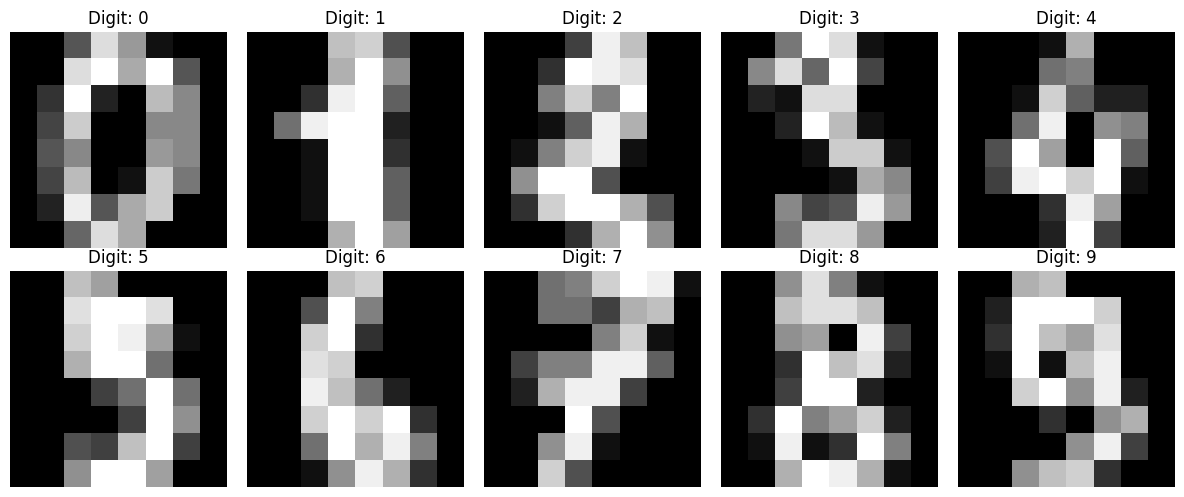

In [17]:
# Visualize sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Digit: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Train-Test Split

In [18]:
# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Training set size: 1437
Test set size: 360

Training set class distribution:
0    142
1    146
2    142
3    146
4    145
5    145
6    145
7    143
8    139
9    144
Name: count, dtype: int64


## 4. Decision Tree Classifier (Multiclass)

In [19]:
# Train Decision Tree Classifier
# Note: Decision trees natively handle multiclass without needing OvA/OvO
# max_depth=8 prevents overfitting (not too shallow, not too deep)
dt_classifier = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained!")
print(f"Tree depth: {dt_classifier.get_depth()}")
print(f"Number of leaves: {dt_classifier.get_n_leaves()}")

Decision Tree Classifier trained!
Tree depth: 8
Number of leaves: 81


In [20]:
# Make predictions
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9388
Test Accuracy: 0.8083


## 5. Multiclass Evaluation Metrics

In [21]:
# Classification Report (multiclass metrics)
print("Classification Report (Test Set):")
print("="*60)
print(classification_report(y_test, y_test_pred))

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        36
           1       0.82      0.64      0.72        36
           2       0.82      0.80      0.81        35
           3       0.76      0.78      0.77        37
           4       0.86      0.83      0.85        36
           5       0.89      0.92      0.91        37
           6       0.88      0.83      0.86        36
           7       0.76      0.81      0.78        36
           8       0.67      0.74      0.70        35
           9       0.73      0.75      0.74        36

    accuracy                           0.81       360
   macro avg       0.81      0.81      0.81       360
weighted avg       0.81      0.81      0.81       360



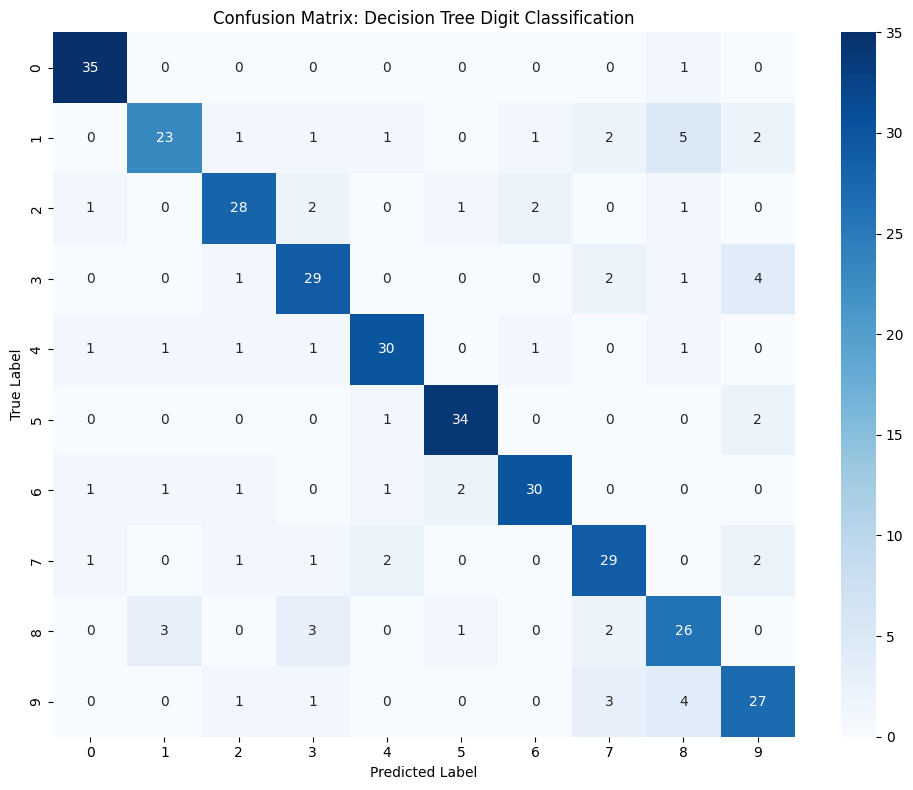

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Decision Tree Digit Classification')
plt.tight_layout()
plt.show()

## 6. Feature Importance

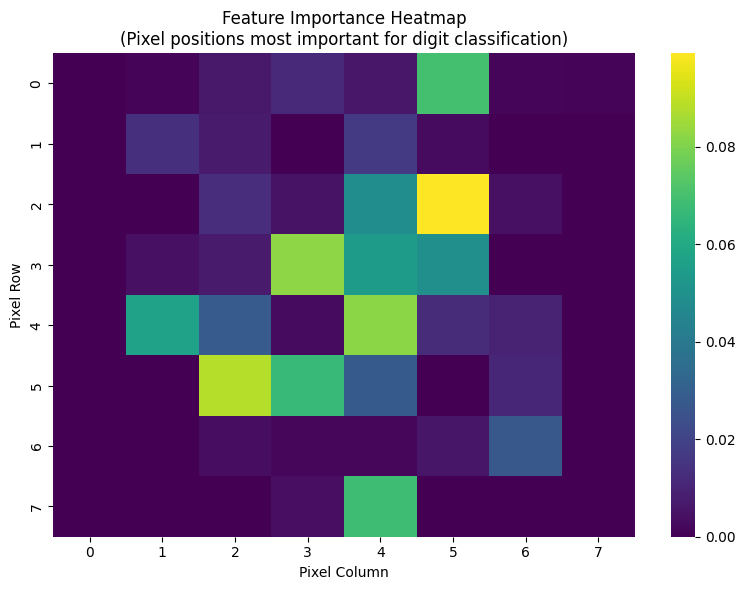

In [23]:
# Get feature importance
feature_importance = dt_classifier.feature_importances_

# Reshape and visualize as heatmap
importance_grid = feature_importance.reshape(8, 8)

plt.figure(figsize=(8, 6))
sns.heatmap(importance_grid, cmap='viridis', cbar=True)
plt.title('Feature Importance Heatmap\n(Pixel positions most important for digit classification)')
plt.xlabel('Pixel Column')
plt.ylabel('Pixel Row')
plt.tight_layout()
plt.show()

In [24]:
# Top 10 most important features
top_indices = np.argsort(feature_importance)[-10:][::-1]
print("Top 10 Most Important Features:")
print("="*40)
for rank, idx in enumerate(top_indices, 1):
    row, col = divmod(idx, 8)
    print(f"{rank}. Pixel [{row}, {col}]: {feature_importance[idx]:.4f}")

Top 10 Most Important Features:
1. Pixel [2, 5]: 0.0993
2. Pixel [5, 2]: 0.0882
3. Pixel [3, 3]: 0.0823
4. Pixel [4, 4]: 0.0820
5. Pixel [0, 5]: 0.0698
6. Pixel [7, 4]: 0.0683
7. Pixel [5, 3]: 0.0669
8. Pixel [4, 1]: 0.0571
9. Pixel [3, 4]: 0.0546
10. Pixel [3, 5]: 0.0493


## 7. Conceptual OvA vs OvO Explanation

### What are OvA (One-vs-All) and OvO (One-vs-One)?

These are strategies to convert **binary classifiers** into **multiclass classifiers**.

#### One-vs-All (OvA)
- Creates **k binary classifiers** (where k = number of classes = 10)
- Classifier 0: Digit 0 vs (1,2,3,4,5,6,7,8,9)
- Classifier 1: Digit 1 vs (0,2,3,4,5,6,7,8,9)
- ... and so on
- Prediction: Returns class with **highest confidence score**
- **Total classifiers**: k = 10

#### One-vs-One (OvO)
- Creates **k(k-1)/2 binary classifiers** (pairs of classes)
- Classifier for (0 vs 1), (0 vs 2), ..., (8 vs 9), etc.
- Prediction: Uses **voting** (which class gets most votes?)
- **Total classifiers**: 10*9/2 = 45

#### Why Decision Trees Don't Need Them
Decision trees **natively handle multiclass** - they split at each node to separate ALL classes simultaneously. They don't need binary conversion strategies.

In [25]:
# Demonstrate OvA/OvO conceptually with Logistic Regression for comparison
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

# OvA Strategy (default for LogisticRegression)
lr_ova = OneVsRestClassifier(LogisticRegression(max_iter=5000, random_state=42))
lr_ova.fit(X_train, y_train)
lr_ova_pred = lr_ova.predict(X_test)
lr_ova_acc = accuracy_score(y_test, lr_ova_pred)

# OvO Strategy
lr_ovo = OneVsOneClassifier(LogisticRegression(max_iter=5000, random_state=42))
lr_ovo.fit(X_train, y_train)
lr_ovo_pred = lr_ovo.predict(X_test)
lr_ovo_acc = accuracy_score(y_test, lr_ovo_pred)

print("Multiclass Strategy Comparison (Logistic Regression):")
print("="*50)
print(f"OvA (One-vs-All) Accuracy: {lr_ova_acc:.4f}")
print(f"OvO (One-vs-One) Accuracy: {lr_ovo_acc:.4f}")
print(f"\nDecision Tree Accuracy:    {test_accuracy:.4f}")

Multiclass Strategy Comparison (Logistic Regression):
OvA (One-vs-All) Accuracy: 0.9583
OvO (One-vs-One) Accuracy: 0.9778

Decision Tree Accuracy:    0.8083


## 8. Summary

### Key Learnings:

1. **Decision Tree Classifier** handles multiclass natively by creating splits that separate all classes simultaneously

2. **OvA (One-vs-All)**: 
   - Creates k binary classifiers
   - For 10 digits: 10 classifiers
   - Prediction based on highest confidence

3. **OvO (One-vs-One)**:
   - Creates k(k-1)/2 binary classifiers
   - For 10 digits: 45 classifiers
   - Prediction based on voting

4. **Performance**: Decision Trees often outperform linear models even without multiclass strategies because they can capture non-linear patterns in the pixel data

### Model Results:
- Test Accuracy: {:.2f}%
- Confusion matrix shows which digits are most commonly misclassified
- Feature importance identifies critical pixels for digit recognition